In [45]:
from CXRO_Tools import Filter_Transmission
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy import interpolate

In [46]:
cxro = Filter_Transmission()
def QE_Acrylic(x, min, max, Si_thickness, SiO2_thickness, C7H10O3_thickness, Re_thickness, Re_coverage, step):
    min=int(min)
    max=int(max)
    step=int(step)
    Si_cxro_data = cxro.get_transmission("Si", thickness = Si_thickness, energy_min=min, energy_max=max, steps=step)
    SiO2_cxro_data = cxro.get_transmission("SiO2", thickness = SiO2_thickness, energy_min=min, energy_max=max, steps=step)
    C7H10O3_cxro_data = cxro.get_transmission("C7H10O3", thickness= C7H10O3_thickness, energy_min=min, energy_max=max, steps=step)
    Re_cxro_data = cxro.get_transmission("Re", thickness= Re_thickness, energy_min=min, energy_max=max, steps=step)
    energies = np.array([i[0] for i in Si_cxro_data])
    Si_transmission = np.array([i[1] for i in Si_cxro_data])
    SiO2_transmission = np.array([i[1] for i in SiO2_cxro_data])
    C7H10O3_transmission = np.array([i[1] for i in C7H10O3_cxro_data])
    Re_transmission = np.array([i[1] for i in Re_cxro_data])


    QE = (((1-Si_transmission) * C7H10O3_transmission * SiO2_transmission)*(1-Re_coverage)) + (((1-Si_transmission) * C7H10O3_transmission * SiO2_transmission * Re_transmission)*Re_coverage)
    interpolated_QE = interpolate.PchipInterpolator(energies, QE)

    return interpolated_QE(x)


In [47]:
def do_QE_fit(x, y, yerr, min, max, step, Si_thickness, SiO2_thickness, C7H10O3_thickness, Re_thickness, Re_coverage):
    QE_model = lmfit.Model(QE_Acrylic)


    QE_params = QE_model.make_params(
        min = min,
        max = max,
        step = step,
        Si_thickness = Si_thickness,
        SiO2_thickness = SiO2_thickness,
        C7H10O3_thickness = C7H10O3_thickness,
        Re_thickness = Re_thickness,
        Re_coverage = Re_coverage
        )

    QE_params['min'].vary = False
    QE_params['max'].vary = False
    QE_params['step'].vary = False
    QE_params['Si_thickness'].vary = True
    QE_params['SiO2_thickness'].vary = True
    QE_params['C7H10O3_thickness'].vary = True
    QE_params['Re_thickness'].vary = True
    QE_params['Re_coverage'].vary = True



    QE_params['Si_thickness'].set(min=2, max=10)
    QE_params['SiO2_thickness'].set(min=0.001)
    QE_params['C7H10O3_thickness'].set(min=0.001)
    QE_params['Re_thickness'].set(min=0.001, max=.5)
    QE_params['Re_coverage'].set(min=0, max=0.5)



    result = QE_model.fit(data = y, params = QE_params, x=x, weights=(1./yerr))
    return result

In [48]:
real_data = np.load("260520_CMOS-QE-Export.npy")
x, y = real_data[0,3:], real_data[1,3:]
yerr = real_data[2,3:]
result = do_QE_fit(x, y, yerr, Si_thickness=5, SiO2_thickness=0.1, C7H10O3_thickness=0.1, Re_thickness=0.1, Re_coverage=.25, min=80, max=1000, step=300)
print(result.fit_report())


[[Model]]
    Model(QE_Acrylic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 83
    # data points      = 17
    # variables        = 5
    chi-square         = 1176.99293
    reduced chi-square = 98.0827443
    Akaike info crit   = 82.0375809
    Bayesian info crit = 86.2036476
    R-squared          = 0.96726143
[[Variables]]
    min:                80 (fixed)
    max:                1000 (fixed)
    Si_thickness:       3.97682865 +/- 0.66498807 (16.72%) (init = 5)
    SiO2_thickness:     0.17739441 +/- 0.01279622 (7.21%) (init = 0.1)
    C7H10O3_thickness:  0.41492621 +/- 0.01810766 (4.36%) (init = 0.1)
    Re_thickness:       0.13306796 +/- 0.06148337 (46.20%) (init = 0.1)
    Re_coverage:        0.25258771 +/- 0.06696631 (26.51%) (init = 0.25)
    step:               300 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(SiO2_thickness, Re_coverage)       = -0.6743
    C(C7H10O3_thickness, Re_coverage)    = -0.6141
    C(Re_thicknes

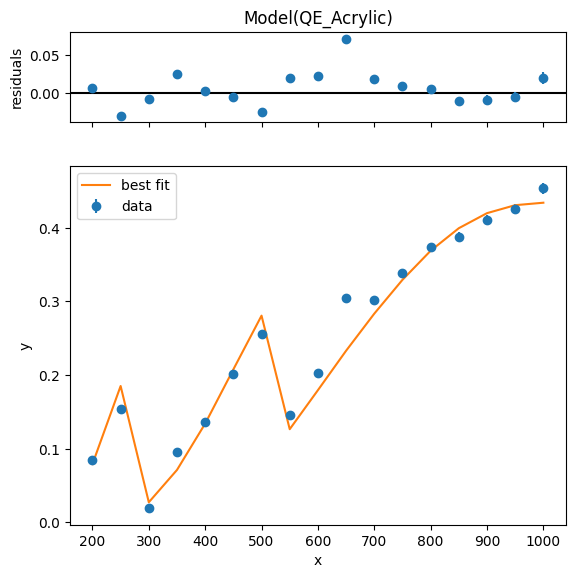

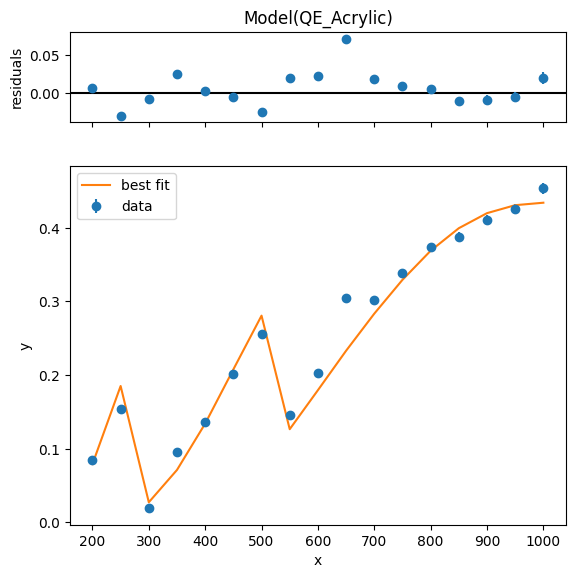

In [49]:
result.plot()